# 分别使用男女足数据训练的 xA 模型

这个 notebook 仿照 enriched_xg_features_competition_events.ipynb：用 statsbombpy.sb.competition_events(...) 读取同一批男女足公开数据，分别训练男足和女足的 xA（expected assists）模型，然后让两个模型都给同一批 held-out 女足测试集传球打分。

主比较使用女足训练集规模下采样后的男足模型 vs 女足模型。


## 0. 这里的 xA 怎么定义？

这里把 xA 定义成一次传球最终为球队制造的射门 xG 期望值。具体标签构造如下：

- 如果一脚传球在 StatsBomb 事件里有 assisted_shot_id，就把被助攻射门的 shot_statsbomb_xg 作为这脚传球的 realized xA label。
- 如果一脚传球没有直接助攻射门，label 就是 0。
- 模型输入使用传球本身的信息：起终点、长度、角度、是否传中 / 倒三角 / 直塞、是否受压、传球高度、身体部位、定位球上下文、传球结果、终点区域等。

因此它不是直接复制 StatsBomb 的 shot-assist 字段，而是在所有传球上训练一个 pass-level expected xA model；之后比较“男足训练出的 pass-to-shot-xG 关系”和“女足训练出的 pass-to-shot-xG 关系”在同一批女足测试传球上的差异。


## 1. Imports 和 constants

依赖应安装在项目 .venv 里。这个 notebook 不在运行时安装依赖，风格和已有 notebook 保持一致。


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from mplsoccer import Pitch
import numpy as np
import pandas as pd
from scipy import stats
from statsbombpy import sb
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
CACHE_DIR = Path("vaep_data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
WOMEN_TEST_SHARE = 0.30

MIN_PASSES_PER_PLAYER = 100
MIN_PASSES_PER_PASS_GROUP = 500
MIN_PLAYERS_FOR_BUCKET_SPEARMAN = 2

print("ready")


ready


## 2. 比赛列表

和 xG / xT / VAEP notebook 使用同一批数据：女足 2023/24 top leagues + NWSL 2023，男足 2015/16 top leagues。


In [2]:
WOMEN_COMPETITIONS = [
    {
        "competition_id": 37,
        "season_id": 281,
        "country": "England",
        "division": "FA Women's Super League",
        "season": "2023/2024",
        "gender": "female",
        "league": "WSL",
    },
    {
        "competition_id": 135,
        "season_id": 281,
        "country": "Germany",
        "division": "Frauen Bundesliga",
        "season": "2023/2024",
        "gender": "female",
        "league": "Frauen Bundesliga",
    },
    {
        "competition_id": 182,
        "season_id": 281,
        "country": "Spain",
        "division": "Liga F",
        "season": "2023/2024",
        "gender": "female",
        "league": "Liga F",
    },
    {
        "competition_id": 131,
        "season_id": 281,
        "country": "Italy",
        "division": "Serie A Women",
        "season": "2023/2024",
        "gender": "female",
        "league": "Serie A Women",
    },
    {
        "competition_id": 49,
        "season_id": 107,
        "country": "United States of America",
        "division": "NWSL",
        "season": "2023",
        "gender": "female",
        "league": "NWSL",
    },
]

MEN_COMPETITIONS = [
    {
        "competition_id": 11,
        "season_id": 27,
        "country": "Spain",
        "division": "La Liga",
        "season": "2015/2016",
        "gender": "male",
        "league": "La Liga",
    },
    {
        "competition_id": 2,
        "season_id": 27,
        "country": "England",
        "division": "Premier League",
        "season": "2015/2016",
        "gender": "male",
        "league": "Premier League",
    },
    {
        "competition_id": 12,
        "season_id": 27,
        "country": "Italy",
        "division": "Serie A",
        "season": "2015/2016",
        "gender": "male",
        "league": "Serie A",
    },
    {
        "competition_id": 7,
        "season_id": 27,
        "country": "France",
        "division": "Ligue 1",
        "season": "2015/2016",
        "gender": "male",
        "league": "Ligue 1",
    },
]


## 3. 加载比赛列表

仍然需要 match list，因为女足 train/test split 要在 game level 做，避免同一场比赛同时进入训练和测试。


In [3]:
def load_remote_matches(competitions, cache_tag):
    """Load remote StatsBomb match lists for a set of competitions."""
    matches_cache = CACHE_DIR / f"{cache_tag}_matches_competition_events_method.pkl"
    if matches_cache.exists():
        print(f"[cache] {cache_tag} matches")
        return pd.read_pickle(matches_cache)

    match_frames = []
    for competition in competitions:
        try:
            matches = sb.matches(
                competition_id=competition["competition_id"],
                season_id=competition["season_id"],
            )
        except Exception as error:
            print("  !", competition["league"], error)
            continue

        matches = matches.copy()
        matches["league"] = competition["league"]
        match_frames.append(matches)
        print(f"[load matches] {competition['league']}: {len(matches)} games")

    all_matches = pd.concat(match_frames, ignore_index=True)
    all_matches.to_pickle(matches_cache)
    return all_matches


women_matches = load_remote_matches(WOMEN_COMPETITIONS, "women")
men_matches = load_remote_matches(MEN_COMPETITIONS, "men2015")

print("women games", len(women_matches), "men games", len(men_matches))


[cache] women matches
[cache] men2015 matches
women games 771 men games 1517


## 4. 共享设置：女足 game-level split

后续所有 xA 比较都只在同一批女足测试比赛上进行。男足下采样模型和女足模型都会给这批相同传球打分。


In [4]:
random_generator = np.random.default_rng(RANDOM_SEED)
women_game_ids = np.sort(women_matches["match_id"].unique())

WOMEN_TEST_GAMES = set(
    random_generator.choice(
        women_game_ids,
        size=int(len(women_game_ids) * WOMEN_TEST_SHARE),
        replace=False,
    )
)

print("women test games:", len(WOMEN_TEST_GAMES), "of", len(women_game_ids))
print("minimum passes per player:", MIN_PASSES_PER_PLAYER)


women test games: 231 of 771
minimum passes per player: 100


## 5. pass / shot 事件辅助函数

这个 notebook 固定使用 `sb.competition_events(..., fmt="dataframe")`，和 xG notebook 一样只读取 flat columns（例如 `pass_assisted_shot_id`、`shot_statsbomb_xg`），不再兼容原始 nested JSON。


In [5]:
def is_missing_value(value):
    """Treat None/NaN/pandas missing scalars as missing."""
    if value is None:
        return True
    try:
        missing = pd.isna(value)
    except (TypeError, ValueError):
        return False
    if missing is pd.NA:
        return True
    if isinstance(missing, (bool, np.bool_)):
        return bool(missing)
    return False


def value_or_default(row, column_name, default=None):
    """Return a flat dataframe column value, falling back only when the column/value is missing."""
    if column_name not in row.index:
        return default
    value = row[column_name]
    return default if is_missing_value(value) else value


FLAT_PASS_REQUIRED_COLUMNS = [
    "id",
    "match_id",
    "player_id",
    "player",
    "team",
    "position",
    "location",
    "pass_end_location",
    "pass_type",
    "pass_height",
    "pass_body_part",
    "pass_technique",
    "pass_outcome",
]
FLAT_SHOT_REQUIRED_COLUMNS = ["id", "shot_statsbomb_xg"]


def require_columns(frame, required_columns, frame_label):
    """Fail fast when competition_events does not return the expected flat dataframe schema."""
    missing_columns = [column for column in required_columns if column not in frame.columns]
    if missing_columns:
        raise ValueError(f"{frame_label} missing expected flat columns: {missing_columns}")


def location_xy(location):
    """Extract x/y from the expected StatsBomb [x, y] location."""
    return float(location[0]), float(location[1])


def distance_and_angle_from_goal_statsbomb(x_coordinate, y_coordinate):
    """Compute distance and visible goal angle from StatsBomb 120x80 coordinates."""
    spadl_x = x_coordinate * 105 / 120
    spadl_y = y_coordinate * 68 / 80
    dx = 105 - spadl_x
    dy = 34 - spadl_y

    distance = np.hypot(dx, dy)
    angle = abs(np.arctan2(7.32 * dx, dx**2 + dy**2 - (7.32 / 2) ** 2))
    return distance, angle


def boolean_flag(value):
    """Convert optional StatsBomb boolean fields to clean booleans."""
    return False if is_missing_value(value) else bool(value)


def pass_context(pass_type, play_pattern):
    """Collapse pass type + play pattern into broad chance-creation contexts."""
    if pass_type == "Corner" or play_pattern == "From Corner":
        return "Corner"
    if pass_type == "Free Kick" or play_pattern == "From Free Kick":
        return "Free Kick"
    if pass_type == "Throw-in" or play_pattern == "From Throw In":
        return "Throw-in"
    if pass_type in {"Goal Kick", "Kick Off"} or play_pattern in {"From Goal Kick", "From Kick Off"}:
        return "Restart"
    if play_pattern == "Regular Play" or pass_type == "Regular Pass":
        return "Open Play"
    return "Other"


def pass_end_zone(end_x, end_y):
    """Bucket the pass end location into broad attacking zones."""
    if end_x >= 102 and 18 <= end_y <= 62:
        return "Penalty Box"
    if end_x >= 80:
        if end_y < 26.7:
            return "Final Third Left"
        if end_y > 53.3:
            return "Final Third Right"
        return "Final Third Central"
    if end_x >= 40:
        return "Middle Third"
    return "Defensive Third"


def build_shot_xg_lookups(shot_events):
    """Build shot-id -> xG and key-pass-id -> xG lookup tables."""
    shot_xg_by_id = {}
    key_pass_xg_by_id = {}

    for _, shot_event in shot_events.iterrows():
        statsbomb_xg = shot_event["shot_statsbomb_xg"]
        if is_missing_value(statsbomb_xg):
            continue
        statsbomb_xg = float(statsbomb_xg)

        shot_xg_by_id[shot_event["id"]] = statsbomb_xg

        key_pass_id = value_or_default(shot_event, "shot_key_pass_id")
        if not is_missing_value(key_pass_id):
            key_pass_xg_by_id[key_pass_id] = statsbomb_xg

    return shot_xg_by_id, key_pass_xg_by_id


def event_to_xa_row(event, league_name, shot_xg_by_id, key_pass_xg_by_id):
    """Convert one StatsBomb pass event into one xA modeling row."""
    start_x, start_y = location_xy(event["location"])
    end_x, end_y = location_xy(event["pass_end_location"])

    pass_length = value_or_default(event, "pass_length")
    if is_missing_value(pass_length):
        pass_length = float(np.hypot(end_x - start_x, end_y - start_y))
    else:
        pass_length = float(pass_length)

    pass_angle = value_or_default(event, "pass_angle")
    if is_missing_value(pass_angle):
        pass_angle = float(np.arctan2(end_y - start_y, end_x - start_x))
    else:
        pass_angle = float(pass_angle)

    start_distance, start_goal_angle = distance_and_angle_from_goal_statsbomb(start_x, start_y)
    end_distance, end_goal_angle = distance_and_angle_from_goal_statsbomb(end_x, end_y)

    play_pattern = value_or_default(event, "play_pattern", "Unknown") or "Unknown"
    pass_type = "Regular Pass" if is_missing_value(event["pass_type"]) else event["pass_type"]
    pass_height = "Unknown" if is_missing_value(event["pass_height"]) else event["pass_height"]
    pass_body_part = "Unknown" if is_missing_value(event["pass_body_part"]) else event["pass_body_part"]
    pass_technique = "None" if is_missing_value(event["pass_technique"]) else event["pass_technique"]
    pass_outcome = "Complete" if is_missing_value(event["pass_outcome"]) else event["pass_outcome"]

    pass_id = event["id"]
    assisted_shot_id = value_or_default(event, "pass_assisted_shot_id")

    target_xa = 0.0
    if not is_missing_value(assisted_shot_id) and assisted_shot_id in shot_xg_by_id:
        target_xa = shot_xg_by_id[assisted_shot_id]
    elif pass_id in key_pass_xg_by_id:
        target_xa = key_pass_xg_by_id[pass_id]

    shot_assist_flag = boolean_flag(value_or_default(event, "pass_shot_assist", False))
    goal_assist_flag = boolean_flag(value_or_default(event, "pass_goal_assist", False))

    return {
        "event_id": pass_id,
        "assisted_shot_id": assisted_shot_id,
        "game_id": int(event["match_id"]),
        "player_id": event["player_id"],
        "player_name": value_or_default(event, "player", "Unknown") or "Unknown",
        "team_name": value_or_default(event, "team", "Unknown") or "Unknown",
        "position_name": value_or_default(event, "position", "Unknown") or "Unknown",
        "league": league_name,
        "start_x": start_x,
        "start_y": start_y,
        "end_x": end_x,
        "end_y": end_y,
        "delta_x": end_x - start_x,
        "delta_y": end_y - start_y,
        "pass_length": pass_length,
        "pass_angle": pass_angle,
        "start_distance_to_goal": start_distance,
        "end_distance_to_goal": end_distance,
        "start_angle_to_goal": start_goal_angle,
        "end_angle_to_goal": end_goal_angle,
        "distance_reduction_to_goal": start_distance - end_distance,
        "pass_type": pass_type,
        "pass_height": pass_height,
        "pass_body_part": pass_body_part,
        "pass_technique": pass_technique,
        "pass_outcome": pass_outcome,
        "play_pattern": play_pattern,
        "pass_context": pass_context(pass_type, play_pattern),
        "end_zone": pass_end_zone(end_x, end_y),
        "under_pressure": boolean_flag(value_or_default(event, "under_pressure", False)),
        "is_cross": boolean_flag(value_or_default(event, "pass_cross", False)),
        "is_cut_back": boolean_flag(value_or_default(event, "pass_cut_back", False)),
        "is_switch": boolean_flag(value_or_default(event, "pass_switch", False)),
        "is_through_ball": boolean_flag(value_or_default(event, "pass_through_ball", False)),
        "is_inswinging": boolean_flag(value_or_default(event, "pass_inswinging", False)),
        "is_outswinging": boolean_flag(value_or_default(event, "pass_outswinging", False)),
        "end_in_box": end_x >= 102 and 18 <= end_y <= 62,
        "end_in_six_yard_box": end_x >= 114 and 30 <= end_y <= 50,
        "is_shot_assist": bool(target_xa > 0 or shot_assist_flag or goal_assist_flag),
        "is_goal_assist": goal_assist_flag,
        "assisted_shot_xg": float(target_xa),
    }


## 6. 加载传球样本并构造 xA label

每个 competition-season 会分别读取 pass events 和 shot events：pass 负责生成特征，shot 负责用 flat columns `pass_assisted_shot_id` / `shot_key_pass_id` 找到对应的 `shot_statsbomb_xg`。


In [6]:
def load_competition_event_xa_passes(competitions, cache_tag):
    """Load pass + shot events with competition_events and convert passes to xA rows."""
    passes_cache = CACHE_DIR / f"{cache_tag}_xa_passes_competition_events_method.pkl"

    if passes_cache.exists():
        print(f"[cache] {cache_tag} competition_events xA passes")
        return pd.read_pickle(passes_cache)

    pass_rows = []

    for competition in competitions:
        try:
            competition_passes = sb.competition_events(
                country=competition["country"],
                division=competition["division"],
                season=competition["season"],
                gender=competition["gender"],
                fmt="dataframe",
                filters={"type": "Pass"},
            )
            competition_shots = sb.competition_events(
                country=competition["country"],
                division=competition["division"],
                season=competition["season"],
                gender=competition["gender"],
                fmt="dataframe",
                filters={"type": "Shot"},
            )
        except Exception as error:
            raise RuntimeError(f"Failed to load pass/shot events for {competition['league']}") from error

        require_columns(competition_passes, FLAT_PASS_REQUIRED_COLUMNS, f"{competition['league']} pass events")
        require_columns(competition_shots, FLAT_SHOT_REQUIRED_COLUMNS, f"{competition['league']} shot events")
        shot_xg_by_id, key_pass_xg_by_id = build_shot_xg_lookups(competition_shots)

        print(
            f"[load competition_events passes] {competition['league']}: "
            f"{len(competition_passes):,} passes | {len(competition_shots):,} shots"
        )

        league_rows = [
            event_to_xa_row(pass_event, competition["league"], shot_xg_by_id, key_pass_xg_by_id)
            for _, pass_event in competition_passes.iterrows()
        ]

        league_frame = pd.DataFrame(league_rows)
        print(
            "   shot-assist passes with xA label:",
            int((league_frame["assisted_shot_xg"] > 0).sum()),
            "| label sum:",
            round(float(league_frame["assisted_shot_xg"].sum()), 2),
        )
        pass_rows.extend(league_rows)

    passes = pd.DataFrame(pass_rows)
    if passes.empty:
        raise ValueError("No pass rows were loaded. Check StatsBomb competition filters and network/cache availability.")
    if passes[["game_id", "player_id"]].isna().any().any():
        raise ValueError("Loaded pass rows contain missing game_id or player_id.")

    passes.to_pickle(passes_cache)
    print(f"[cache] wrote {cache_tag} competition_events xA passes: {len(passes):,} passes")
    return passes


women_passes = load_competition_event_xa_passes(WOMEN_COMPETITIONS, "women")
men_passes = load_competition_event_xa_passes(MEN_COMPETITIONS, "men2015")

women_train_passes = women_passes[~women_passes.game_id.isin(WOMEN_TEST_GAMES)].copy()
women_test_passes = women_passes[women_passes.game_id.isin(WOMEN_TEST_GAMES)].copy()

print(
    f"xA pass samples | men train={len(men_passes):,} "
    f"women train={len(women_train_passes):,} women test={len(women_test_passes):,}"
)
print(
    f"shot-assist labels | men={int((men_passes.assisted_shot_xg > 0).sum()):,} "
    f"women train={int((women_train_passes.assisted_shot_xg > 0).sum()):,} "
    f"women test={int((women_test_passes.assisted_shot_xg > 0).sum()):,}"
)


[cache] women competition_events xA passes
[cache] men2015 competition_events xA passes
xA pass samples | men train=1,481,813 women train=503,185 women test=212,402
shot-assist labels | men=27,035 women train=9,646 women test=4,044


## 7. input 数据预处理

这里先把男足训练集下采样到女足训练集规模，再用男足下采样训练集 + 女足训练集构建共享 one-hot feature schema。


In [7]:
NUMERIC_XA_FEATURES = [
    "start_x",
    "start_y",
    "end_x",
    "end_y",
    "delta_x",
    "delta_y",
    "pass_length",
    "pass_angle",
    "start_distance_to_goal",
    "end_distance_to_goal",
    "start_angle_to_goal",
    "end_angle_to_goal",
    "distance_reduction_to_goal",
]

BOOLEAN_XA_FEATURES = [
    "under_pressure",
    "is_cross",
    "is_cut_back",
    "is_switch",
    "is_through_ball",
    "is_inswinging",
    "is_outswinging",
    "end_in_box",
    "end_in_six_yard_box",
]

CATEGORICAL_XA_FEATURES = [
    "pass_type",
    "pass_height",
    "pass_body_part",
    "pass_technique",
    "pass_outcome",
    "play_pattern",
    "pass_context",
    "end_zone",
]

XA_BASE_FEATURES = NUMERIC_XA_FEATURES + BOOLEAN_XA_FEATURES + CATEGORICAL_XA_FEATURES


def build_xa_design_matrix(passes, expected_columns=None):
    """Turn pass rows into the numeric matrix expected by XGBoost."""
    features = passes[XA_BASE_FEATURES].copy()

    for column in NUMERIC_XA_FEATURES:
        features[column] = pd.to_numeric(features[column], errors="coerce").fillna(0.0)
    for column in BOOLEAN_XA_FEATURES:
        features[column] = features[column].fillna(False).astype(int)
    for column in CATEGORICAL_XA_FEATURES:
        features[column] = features[column].fillna("Unknown").astype(str)

    features = pd.get_dummies(features, columns=CATEGORICAL_XA_FEATURES, dtype=float)
    if expected_columns is not None:
        features = features.reindex(columns=expected_columns, fill_value=0.0)
    return features


downsample_size = len(women_train_passes)
if len(men_passes) < downsample_size:
    raise ValueError("Men pass sample is smaller than women train sample; cannot downsample as planned.")

men_downsampled_passes = men_passes.sample(
    n=downsample_size,
    random_state=RANDOM_SEED,
    replace=False,
).copy()

training_passes_for_feature_schema = pd.concat(
    [men_downsampled_passes, women_train_passes],
    ignore_index=True,
)
xa_feature_columns = build_xa_design_matrix(training_passes_for_feature_schema).columns

men_downsampled_features = build_xa_design_matrix(men_downsampled_passes, expected_columns=xa_feature_columns)
women_train_features = build_xa_design_matrix(women_train_passes, expected_columns=xa_feature_columns)
women_test_features = build_xa_design_matrix(women_test_passes, expected_columns=xa_feature_columns)

print("xA base features:", XA_BASE_FEATURES)
print("shared one-hot model columns:", len(xa_feature_columns))
print(
    "feature matrix shapes | "
    f"men_downsampled={men_downsampled_features.shape} "
    f"women_train={women_train_features.shape} "
    f"women_test={women_test_features.shape}"
)


xA base features: ['start_x', 'start_y', 'end_x', 'end_y', 'delta_x', 'delta_y', 'pass_length', 'pass_angle', 'start_distance_to_goal', 'end_distance_to_goal', 'start_angle_to_goal', 'end_angle_to_goal', 'distance_reduction_to_goal', 'under_pressure', 'is_cross', 'is_cut_back', 'is_switch', 'is_through_ball', 'is_inswinging', 'is_outswinging', 'end_in_box', 'end_in_six_yard_box', 'pass_type', 'pass_height', 'pass_body_part', 'pass_technique', 'pass_outcome', 'play_pattern', 'pass_context', 'end_zone']
shared one-hot model columns: 73
feature matrix shapes | men_downsampled=(503185, 73) women_train=(503185, 73) women_test=(212402, 73)


## 8. 训练 xA 模型并给同一批女足 test passes 打分

训练两个模型：男足下采样模型和女足模型。主比较使用 downsampled men vs women。


In [8]:
def train_xa_model(features, target, model_label):
    """Train one pass-level expected-assist regressor."""
    model = XGBRegressor(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="reg:squarederror",
        random_state=RANDOM_SEED,
        n_jobs=4,
    )
    model.fit(features, target)
    print(f"[trained] {model_label}: rows={len(features):,} target_sum={target.sum():.2f}")
    return model


def predict_xa(model, features):
    """Predict xA and clip to the natural [0, 1] xG scale."""
    return np.clip(model.predict(features), 0.0, 1.0)


men_downsampled_xa_model = train_xa_model(
    men_downsampled_features,
    men_downsampled_passes["assisted_shot_xg"],
    "men downsampled xA",
)
women_xa_model = train_xa_model(
    women_train_features,
    women_train_passes["assisted_shot_xg"],
    "women xA",
)

xa_predictions = women_test_passes.copy()
xa_predictions["men_downsampled_model_xa"] = predict_xa(men_downsampled_xa_model, women_test_features)
xa_predictions["women_model_xa"] = predict_xa(women_xa_model, women_test_features)
xa_predictions["xa_delta"] = xa_predictions["men_downsampled_model_xa"] - xa_predictions["women_model_xa"]

print("Training pass counts:")
print(f"- men downsampled: {len(men_downsampled_passes):,}")
print(f"- women train: {len(women_train_passes):,}")
print(f"- women test: {len(women_test_passes):,}")


[trained] men downsampled xA: rows=503,185 target_sum=861.68
[trained] women xA: rows=503,185 target_sum=978.15
Training pass counts:
- men downsampled: 503,185
- women train: 503,185
- women test: 212,402


## 9. 球员位置、门将过滤和 Spearman helper

优先使用已有 position cache；如果没有，就从本 notebook 的女足 pass rows 里抽取球员位置。


In [9]:
POSITION_CACHE_CANDIDATES = [
    CACHE_DIR / "women_positions_competition_events_method.pkl",
    CACHE_DIR / "women_positions_statsbombpy_remote.pkl",
    CACHE_DIR / "women_pos.parquet",
]


def load_women_position_rows(fallback_passes=None):
    """Load cached women player-position observations, or use pass-row fallback."""
    for position_cache in POSITION_CACHE_CANDIDATES:
        if position_cache.exists():
            print(f"[cache] women positions: {position_cache}")
            if position_cache.suffix == ".parquet":
                positions = pd.read_parquet(position_cache).copy()
            else:
                positions = pd.read_pickle(position_cache).copy()
            break
    else:
        if fallback_passes is None:
            raise FileNotFoundError("No women position cache found and no fallback pass rows were provided.")
        print("[fallback] women positions from xA pass rows")
        positions = fallback_passes[["player_id", "position_name"]].copy()

    required_columns = {"player_id", "position_name"}
    missing_columns = required_columns.difference(positions.columns)
    if missing_columns:
        raise ValueError(f"Position cache missing columns: {sorted(missing_columns)}")

    positions = positions[list(required_columns)].dropna().copy()
    positions["player_id_key"] = pd.to_numeric(positions["player_id"], errors="coerce").astype("Int64")
    positions["position_name"] = positions["position_name"].astype(str)
    positions = positions.dropna(subset=["player_id_key", "position_name"])
    return positions


def build_primary_position_table(position_rows):
    """Choose the most frequent observed position for each player."""
    position_counts = (
        position_rows.groupby(["player_id_key", "position_name"])
        .size()
        .reset_index(name="position_observations")
        .sort_values(["player_id_key", "position_observations", "position_name"], ascending=[True, False, True])
    )

    return (
        position_counts.groupby("player_id_key", as_index=False)
        .first()
        .rename(columns={"position_name": "primary_position"})
    )


def bucket_position(position_name):
    """Map granular StatsBomb positions to broad tactical buckets."""
    position_name = str(position_name)

    if "Goalkeeper" in position_name:
        return "Goalkeeper"
    if "Center Back" in position_name:
        return "Center Back"
    if "Wing Back" in position_name or position_name in {"Left Back", "Right Back"}:
        return "Fullback / Wing Back"
    if "Defensive Midfield" in position_name:
        return "Defensive Midfield"
    if "Center Midfield" in position_name:
        return "Central Midfield"
    if "Attacking Midfield" in position_name:
        return "Attacking Midfield"
    if position_name in {"Left Midfield", "Right Midfield", "Left Wing", "Right Wing"}:
        return "Wide Midfielder / Winger"
    if "Center Forward" in position_name or position_name == "Striker":
        return "Forward"
    return "Other / Unknown"


def spearman_if_available(left, right, min_observations=2):
    """Return Spearman correlation when there are enough non-constant observations."""
    paired_values = pd.DataFrame({"left": left, "right": right}).dropna()
    if len(paired_values) < min_observations:
        return np.nan
    if paired_values["left"].nunique(dropna=True) < 2 or paired_values["right"].nunique(dropna=True) < 2:
        return np.nan
    return stats.spearmanr(paired_values["left"], paired_values["right"])[0]


women_position_rows = load_women_position_rows(women_passes)
primary_positions = build_primary_position_table(women_position_rows)
primary_positions["position_bucket"] = primary_positions["primary_position"].map(bucket_position)
goalkeeper_player_id_keys = set(
    primary_positions.loc[primary_positions["position_bucket"].eq("Goalkeeper"), "player_id_key"]
)

print("primary-position rows:", len(primary_positions))
print("goalkeepers identified:", len(goalkeeper_player_id_keys))


[cache] women positions: vaep_data\women_positions_competition_events_method.pkl
primary-position rows: 1241
goalkeepers identified: 1


## 10. 球员层面汇总：男足 xA vs 女足 xA

按球员把 pass-level xA 加总，再比较两个模型下的球员排名。这里排除门将，并要求测试集传球数达到阈值。


In [10]:
player_xa_comparison_all = (
    xa_predictions.groupby("player_id")
    .agg(
        player_name=("player_name", "first"),
        men_downsampled_xa=("men_downsampled_model_xa", "sum"),
        women_xa=("women_model_xa", "sum"),
        observed_xa=("assisted_shot_xg", "sum"),
        pass_count=("women_model_xa", "size"),
        shot_assist_count=("is_shot_assist", "sum"),
        goal_assist_count=("is_goal_assist", "sum"),
    )
    .reset_index()
)

player_xa_comparison_all["player_id_key"] = pd.to_numeric(
    player_xa_comparison_all["player_id"],
    errors="coerce",
).astype("Int64")

player_xa_comparison_all = player_xa_comparison_all.merge(
    primary_positions,
    on="player_id_key",
    how="left",
)
player_xa_comparison_all["primary_position"] = player_xa_comparison_all["primary_position"].fillna("Unknown")
player_xa_comparison_all["position_bucket"] = player_xa_comparison_all["position_bucket"].fillna("Other / Unknown")
player_xa_comparison_all["xa_delta"] = (
    player_xa_comparison_all["men_downsampled_xa"] - player_xa_comparison_all["women_xa"]
)
player_xa_comparison_all["abs_xa_delta"] = player_xa_comparison_all["xa_delta"].abs()

player_xa_comparison = player_xa_comparison_all[
    (player_xa_comparison_all["pass_count"] >= MIN_PASSES_PER_PLAYER)
    & (~player_xa_comparison_all["player_id_key"].isin(goalkeeper_player_id_keys))
].copy()

rho_xa = spearman_if_available(
    player_xa_comparison["men_downsampled_xa"],
    player_xa_comparison["women_xa"],
)

print(f"xA | players={len(player_xa_comparison)} | Spearman downsampled men vs women={rho_xa:.3f}")
print("Total predicted xA on women test passes:")
print(f"- men downsampled model: {xa_predictions['men_downsampled_model_xa'].sum():.2f}")
print(f"- women model: {xa_predictions['women_model_xa'].sum():.2f}")
print(f"- realized assisted-shot xG label: {xa_predictions['assisted_shot_xg'].sum():.2f}")

display(
    player_xa_comparison.sort_values("abs_xa_delta", ascending=False)[
        [
            "player_id",
            "player_name",
            "primary_position",
            "position_bucket",
            "pass_count",
            "shot_assist_count",
            "observed_xa",
            "men_downsampled_xa",
            "women_xa",
            "xa_delta",
        ]
    ].head(20).round(4)
)


xA | players=775 | Spearman downsampled men vs women=0.993
Total predicted xA on women test passes:
- men downsampled model: 425.53
- women model: 418.60
- realized assisted-shot xG label: 408.48


,player_id,player_name,primary_position,position_bucket,pass_count,shot_assist_count,observed_xa,men_downsampled_xa,women_xa,xa_delta
479,42247,Morgan Weaver,Left Wing,Wide Midfielder / Winger,220,20,3.3766,2.5778,2.1368,0.4410
785,50369,Maddi Torre Larrañaga,Left Center Back,Center Back,595,5,0.8082,0.7776,1.0537,-0.2761
1237,389495,Alyssa Paola Thompson,Left Wing,Wide Midfielder / Winger,106,5,0.9332,0.8001,1.0643,-0.2642
1137,321797,Marina Martí Serna,Right Wing,Wide Midfielder / Winger,123,7,1.1065,1.3000,1.0688,0.2312
875,81477,Claudia Iglesias de la Cruz,Left Center Midfield,Central Midfield,430,8,0.6463,0.9438,1.1713,-0.2275
341,25834,Viviane Asseyi,Left Wing,Wide Midfielder / Winger,150,5,0.5163,1.1230,0.8992,0.2238
68,5044,Débora Cristiane de Oliveira,Center Attacking Midfield,Attacking Midfield,153,6,0.7497,1.0041,1.2204,-0.2163
118,10108,Pernille Mosegaard Harder,Center Attacking Midfield,Attacking Midfield,174,14,1.8833,1.6617,1.4489,0.2128
179,10386,Caroline Graham Hansen,Right Wing,Wide Midfielder / Winger,145,16,2.0998,2.5173,2.3102,0.2071
322,25608,Jun Endo,Left Wing,Wide Midfielder / Winger,155,13,0.9346,1.2552,1.0504,0.2049


## 11. 球员 scatter：同一批女足 test passes，不同训练数据模型

点越贴近对角线，说明男足训练模型和女足训练模型对球员 xA 总量 / 排名越接近。


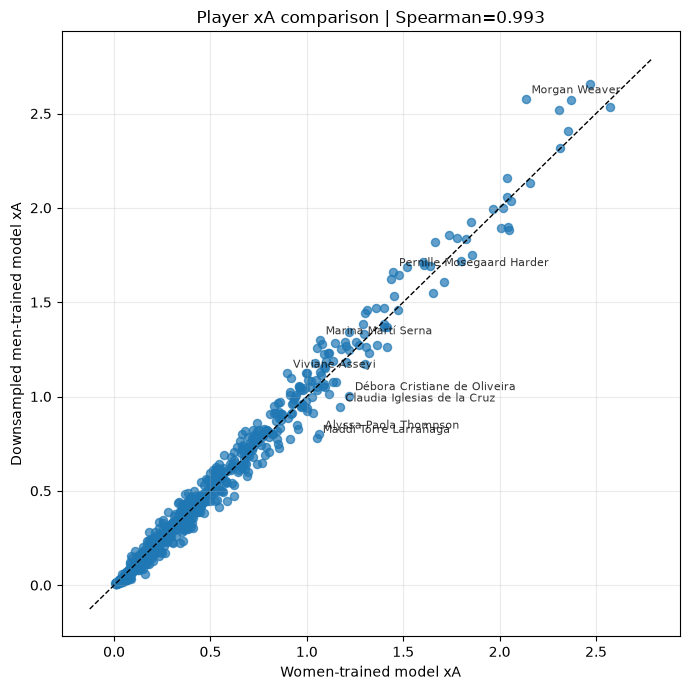

In [11]:
if player_xa_comparison.empty:
    print("No players passed the filtering threshold; lower MIN_PASSES_PER_PLAYER if needed.")
else:
    fig, axis = plt.subplots(figsize=(7, 7))

    axis.scatter(
        player_xa_comparison["women_xa"],
        player_xa_comparison["men_downsampled_xa"],
        alpha=0.70,
        s=34,
    )

    axis_min = min(player_xa_comparison["women_xa"].min(), player_xa_comparison["men_downsampled_xa"].min())
    axis_max = max(player_xa_comparison["women_xa"].max(), player_xa_comparison["men_downsampled_xa"].max())
    padding = (axis_max - axis_min) * 0.05 if axis_max > axis_min else 0.1
    axis.plot(
        [axis_min - padding, axis_max + padding],
        [axis_min - padding, axis_max + padding],
        linestyle="--",
        color="black",
        linewidth=1,
    )

    for _, row in player_xa_comparison.sort_values("abs_xa_delta", ascending=False).head(8).iterrows():
        label = row["player_name"] if row["player_name"] != "Unknown" else str(row["player_id"])
        axis.annotate(
            label,
            (row["women_xa"], row["men_downsampled_xa"]),
            fontsize=8,
            alpha=0.8,
            xytext=(4, 4),
            textcoords="offset points",
        )

    axis.set_xlabel("Women-trained model xA")
    axis.set_ylabel("Downsampled men-trained model xA")
    axis.set_title(f"Player xA comparison | Spearman={rho_xa:.3f}")
    axis.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


## 12. 模型预测和 realized xA label 的关系

assisted_shot_xg 是稀疏 realized label，不是真正的 ground-truth expectation；所以这里主要看整体尺度、相关性和误差，避免把单脚传球层面的误差过度解读。


,source,passes,shot_assist_passes,total_predicted_xa,total_realized_xa,mean_predicted_xa,mae_vs_realized_xa,rmse_vs_realized_xa,mae_on_shot_assists,pearson_vs_realized_xa,spearman_vs_realized_xa
0,men_downsampled_model_xa,212402,4044,425.53335,408.48461,0.00200,0.00176,0.01393,0.04985,0.75178,0.22007
1,women_model_xa,212402,4044,418.60113,408.48461,0.00197,0.00177,0.01392,0.05022,0.75219,0.22107


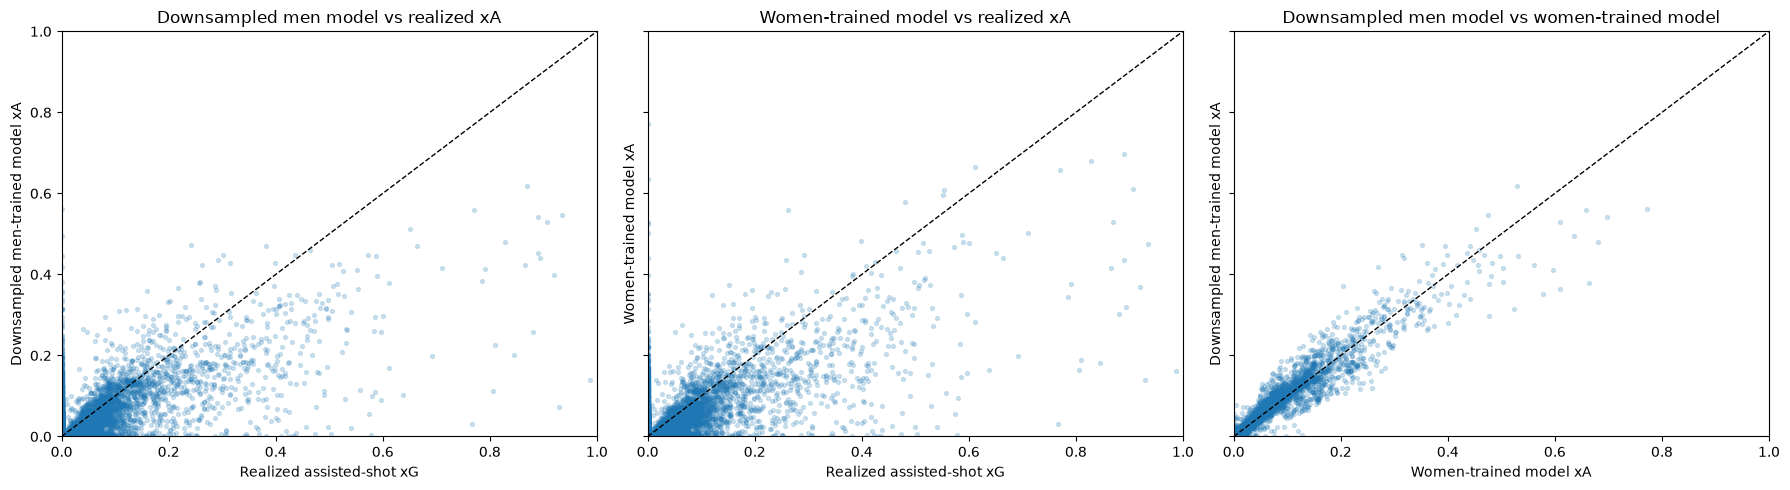

In [12]:
observed_xa = xa_predictions["assisted_shot_xg"].astype(float)
shot_assist_mask = observed_xa > 0

comparison_rows = []
for source_label, prediction_column in [
    ("men_downsampled_model_xa", "men_downsampled_model_xa"),
    ("women_model_xa", "women_model_xa"),
]:
    prediction = xa_predictions[prediction_column].astype(float)
    comparison_rows.append(
        {
            "source": source_label,
            "passes": len(prediction),
            "shot_assist_passes": int(shot_assist_mask.sum()),
            "total_predicted_xa": prediction.sum(),
            "total_realized_xa": observed_xa.sum(),
            "mean_predicted_xa": prediction.mean(),
            "mae_vs_realized_xa": np.mean(np.abs(prediction - observed_xa)),
            "rmse_vs_realized_xa": np.sqrt(np.mean((prediction - observed_xa) ** 2)),
            "mae_on_shot_assists": (
                np.mean(np.abs(prediction[shot_assist_mask] - observed_xa[shot_assist_mask]))
                if shot_assist_mask.any()
                else np.nan
            ),
            "pearson_vs_realized_xa": prediction.corr(observed_xa, method="pearson"),
            "spearman_vs_realized_xa": prediction.corr(observed_xa, method="spearman"),
        }
    )

model_vs_realized_xa = pd.DataFrame(comparison_rows)
display(model_vs_realized_xa.round(5))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
scatter_specs = [
    (
        "assisted_shot_xg",
        "men_downsampled_model_xa",
        "Realized assisted-shot xG",
        "Downsampled men-trained model xA",
        "Downsampled men model vs realized xA",
    ),
    (
        "assisted_shot_xg",
        "women_model_xa",
        "Realized assisted-shot xG",
        "Women-trained model xA",
        "Women-trained model vs realized xA",
    ),
    (
        "women_model_xa",
        "men_downsampled_model_xa",
        "Women-trained model xA",
        "Downsampled men-trained model xA",
        "Downsampled men model vs women-trained model",
    ),
]

max_xa = xa_predictions[["assisted_shot_xg", "men_downsampled_model_xa", "women_model_xa"]].max().max()
axis_limit = min(1.0, max(0.02, max_xa * 1.05))

for axis, (x_column, y_column, x_label, y_label, title) in zip(axes, scatter_specs):
    axis.scatter(
        xa_predictions[x_column],
        xa_predictions[y_column],
        alpha=0.20,
        s=8,
    )
    axis.plot([0, axis_limit], [0, axis_limit], linestyle="--", color="black", linewidth=1)
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.set_xlim(0, axis_limit)
    axis.set_ylim(0, axis_limit)

plt.tight_layout()
plt.show()


## 13. 按传球终点 grid 比较模型差异

这里把女足测试集传球按照终点位置落到 12x16 grid，观察哪些区域的 men_downsampled_model_xa - women_model_xa 更大。


In [13]:
XA_GRID_ROWS = 12
XA_GRID_COLS = 16
MIN_GRID_PASSES = 200
STATSBOMB_PITCH_LENGTH = 120.0
STATSBOMB_PITCH_WIDTH = 80.0


def add_xa_end_grid_columns(passes, rows=XA_GRID_ROWS, cols=XA_GRID_COLS):
    """Assign each pass to a grid cell based on end location."""
    passes = passes.copy()
    valid_coordinates = passes[["end_x", "end_y"]].notna().all(axis=1)
    passes = passes[valid_coordinates].copy()

    passes["grid_col"] = np.floor(passes["end_x"] / STATSBOMB_PITCH_LENGTH * cols).astype(int).clip(0, cols - 1)
    passes["grid_row"] = np.floor(passes["end_y"] / STATSBOMB_PITCH_WIDTH * rows).astype(int).clip(0, rows - 1)
    return passes


def summarize_xa_delta_by_end_grid(passes, rows=XA_GRID_ROWS, cols=XA_GRID_COLS):
    """Summarize pass-level xA deltas by pass end-location grid."""
    passes_with_grid = add_xa_end_grid_columns(passes, rows=rows, cols=cols)
    passes_with_grid["xa_delta"] = passes_with_grid["men_downsampled_model_xa"] - passes_with_grid["women_model_xa"]

    all_cells = pd.MultiIndex.from_product(
        [range(rows), range(cols)],
        names=["grid_row", "grid_col"],
    ).to_frame(index=False)

    grid_summary = (
        passes_with_grid.groupby(["grid_row", "grid_col"])
        .agg(
            pass_count=("xa_delta", "size"),
            observed_xa=("assisted_shot_xg", "sum"),
            men_downsampled_xa=("men_downsampled_model_xa", "sum"),
            women_xa=("women_model_xa", "sum"),
            aggregate_xa_delta=("xa_delta", "sum"),
            mean_xa_delta=("xa_delta", "mean"),
            median_xa_delta=("xa_delta", "median"),
            mean_women_xa=("women_model_xa", "mean"),
            mean_men_downsampled_xa=("men_downsampled_model_xa", "mean"),
        )
        .reset_index()
    )

    grid_summary = all_cells.merge(grid_summary, on=["grid_row", "grid_col"], how="left")
    count_columns = ["pass_count"]
    sum_columns = ["observed_xa", "men_downsampled_xa", "women_xa", "aggregate_xa_delta"]
    grid_summary[count_columns + sum_columns] = grid_summary[count_columns + sum_columns].fillna(0)
    return passes_with_grid, grid_summary


xa_grid_predictions, xa_grid_delta_summary = summarize_xa_delta_by_end_grid(xa_predictions)
valid_grid_mask = xa_grid_delta_summary["pass_count"] >= MIN_GRID_PASSES

print("Grid delta definition: men_downsampled_model_xa - women_model_xa")
print(f"women test passes assigned to grid: {len(xa_grid_predictions):,} of {len(xa_predictions):,}")
print(f"non-empty grid cells: {(xa_grid_delta_summary.pass_count > 0).sum()} of {len(xa_grid_delta_summary)}")
print(f"grid cells with at least {MIN_GRID_PASSES} passes: {valid_grid_mask.sum()} of {len(xa_grid_delta_summary)}")

print("\nLargest absolute aggregate deltas by pass end grid:")
display(
    xa_grid_delta_summary[valid_grid_mask]
    .assign(abs_aggregate_delta=lambda frame: frame["aggregate_xa_delta"].abs())
    .sort_values("abs_aggregate_delta", ascending=False)
    .head(20)
    .round(5)
)


Grid delta definition: men_downsampled_model_xa - women_model_xa
women test passes assigned to grid: 212,402 of 212,402
non-empty grid cells: 192 of 192
grid cells with at least 200 passes: 186 of 192

Largest absolute aggregate deltas by pass end grid:


,grid_row,grid_col,pass_count,observed_xa,men_downsampled_xa,women_xa,aggregate_xa_delta,mean_xa_delta,median_xa_delta,mean_women_xa,mean_men_downsampled_xa,abs_aggregate_delta
110,6,14,1803,53.64577,57.574680,52.144642,5.43004,0.00301,0.00000,0.02892,0.03193,5.43004
94,5,14,1823,46.81530,55.082359,49.766979,5.31538,0.00292,0.00000,0.02730,0.03022,5.31538
109,6,13,844,17.67355,17.081921,15.653180,1.42873,0.00169,0.00000,0.01855,0.02024,1.42873
126,7,14,1069,19.01004,20.549721,19.216740,1.33298,0.00125,0.00000,0.01798,0.01922,1.33298
76,4,12,870,4.83367,5.482700,6.766780,-1.28408,-0.00148,-0.00024,0.00778,0.00630,1.28408
93,5,13,828,15.00099,15.941550,14.750210,1.19134,0.00144,0.00000,0.01781,0.01925,1.19134
79,4,15,612,6.92297,7.636630,6.769380,0.86726,0.00142,0.00000,0.01106,0.01248,0.86726
127,7,15,724,6.73667,8.203440,7.340700,0.86274,0.00119,0.00000,0.01014,0.01133,0.86274
78,4,14,1027,18.75061,17.507370,16.761129,0.74624,0.00073,0.00000,0.01632,0.01705,0.74624
124,7,12,828,3.96359,4.251710,4.985860,-0.73416,-0.00089,-0.00010,0.00602,0.00513,0.73416


## 13.1 传球终点 grid visualization

左图看女足测试集传球终点分布，右图看每个终点区域的平均模型差异。


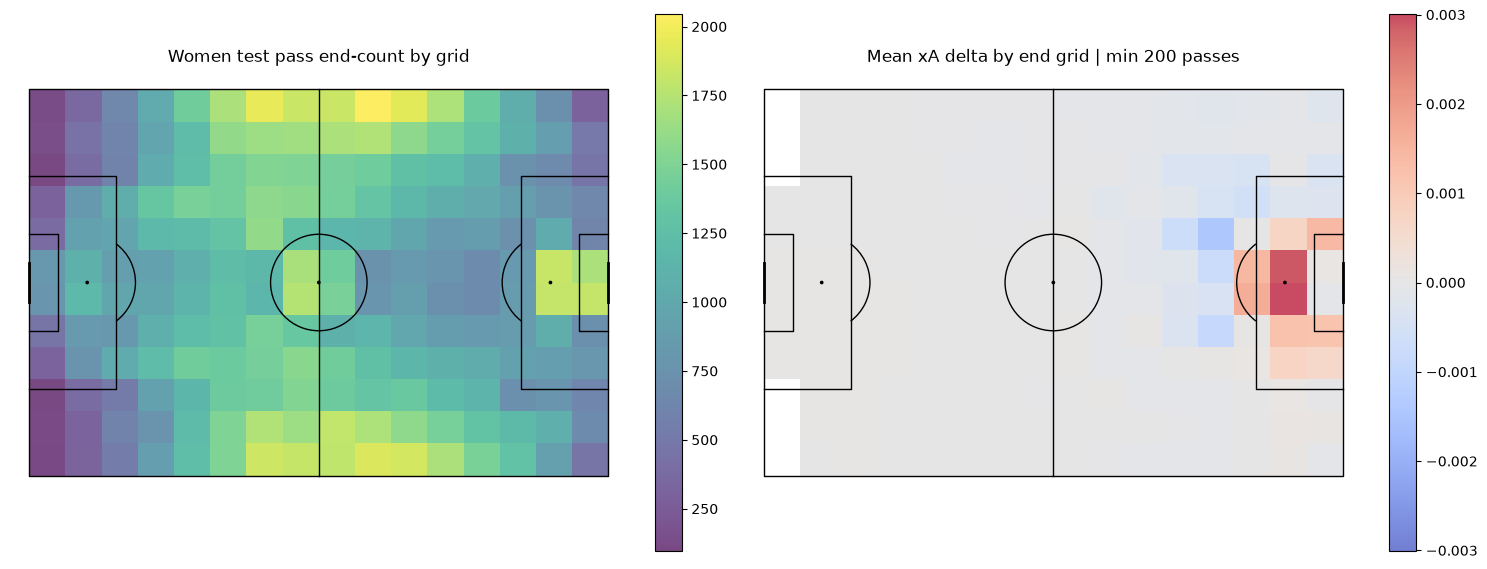

In [14]:
def grid_metric_matrix(grid_summary, metric, rows=XA_GRID_ROWS, cols=XA_GRID_COLS, min_passes=None):
    """Convert long grid summary into a rows x cols matrix."""
    matrix = np.full((rows, cols), np.nan)
    for _, row in grid_summary.iterrows():
        if min_passes is not None and row["pass_count"] < min_passes:
            continue
        matrix[int(row["grid_row"]), int(row["grid_col"])] = row[metric]
    return matrix


def plot_xa_grid_heatmap(axis, grid_summary, metric, title, cmap="viridis", center_zero=False, min_passes=None):
    """Draw one pitch heatmap from a grid metric."""
    pitch = Pitch(pitch_type="statsbomb", pitch_color="white", line_color="black", linewidth=1)
    pitch.draw(ax=axis)

    matrix = grid_metric_matrix(grid_summary, metric, min_passes=min_passes)
    if np.all(np.isnan(matrix)):
        axis.set_title(title + " (no valid cells)")
        return None

    if center_zero:
        value_limit = np.nanmax(np.abs(matrix))
        value_limit = value_limit if value_limit > 0 else 1e-6
        vmin, vmax = -value_limit, value_limit
    else:
        vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)

    image = axis.imshow(
        matrix,
        extent=(0, STATSBOMB_PITCH_LENGTH, STATSBOMB_PITCH_WIDTH, 0),
        origin="upper",
        cmap=cmap,
        alpha=0.72,
        vmin=vmin,
        vmax=vmax,
    )
    axis.set_title(title)
    return image


fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
image_0 = plot_xa_grid_heatmap(
    axes[0],
    xa_grid_delta_summary,
    "pass_count",
    "Women test pass end-count by grid",
    cmap="viridis",
)
image_1 = plot_xa_grid_heatmap(
    axes[1],
    xa_grid_delta_summary,
    "mean_xa_delta",
    f"Mean xA delta by end grid | min {MIN_GRID_PASSES} passes",
    cmap="coolwarm",
    center_zero=True,
    min_passes=MIN_GRID_PASSES,
)

for axis, image in zip(axes, [image_0, image_1]):
    if image is not None:
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 14. 按 pass context / end zone 分析模型差异

xA 全部来自传球，所以这里不按 action type，而是按传球上下文、终点区域、传球高度等 pass profile 来看差异。

2D ridgeline 图的读法：每一行是一个 pass group 的 pass-level xA delta 分布；隆起越高，说明该 delta 附近的传球越多。每一行颜色表示该 group 的 mean xA delta：偏蓝表示女足模型平均给分更高，偏红表示男足模型平均给分更高。黑点标出该 group 的 mean delta。



pass_context groups with at least 500 passes:


,pass_context,passes,shot_assist_passes,observed_xa,men_downsampled_xa,women_xa,aggregate_xa_delta,mean_xa_delta,median_xa_delta,mean_men_downsampled_xa,mean_women_xa
3,Other,1111,46,5.04329,4.495540,4.682010,-0.18646,-0.00017,0.0,0.00405,0.00421
2,Open Play,97897,1807,199.51062,193.337662,195.946274,-2.60863,-0.00003,0.0,0.00197,0.00200
4,Restart,25050,213,21.61135,20.266239,20.265200,0.00104,0.00000,0.0,0.00081,0.00081
5,Throw-in,55590,835,71.45461,80.333443,78.464348,1.86910,0.00003,0.0,0.00145,0.00141
1,Free Kick,26126,525,51.58695,57.658932,55.913509,1.74542,0.00007,0.0,0.00221,0.00214
0,Corner,6628,618,59.27779,69.441544,63.329781,6.11175,0.00092,0.0,0.01048,0.00955



end_zone groups with at least 500 passes:


,end_zone,passes,shot_assist_passes,observed_xa,men_downsampled_xa,women_xa,aggregate_xa_delta,mean_xa_delta,median_xa_delta,mean_men_downsampled_xa,mean_women_xa
1,Final Third Central,9316,797,54.96980,56.950008,61.044399,-4.094380,-0.00044,0.00000,0.00611,0.00655
2,Final Third Left,18664,390,20.62474,13.776600,17.629141,-3.852540,-0.00021,-0.00006,0.00074,0.00094
4,Middle Third,95179,226,8.30383,11.377760,14.504290,-3.126520,-0.00003,0.00000,0.00012,0.00015
3,Final Third Right,20137,306,15.65487,14.309340,14.629750,-0.320410,-0.00002,-0.00001,0.00071,0.00073
0,Defensive Third,52880,2,0.03667,3.230640,2.719860,0.510790,0.00001,0.00002,0.00006,0.00005
5,Penalty Box,16226,2323,308.89468,325.888977,308.073700,17.815281,0.00110,0.00000,0.02008,0.01899



pass_height groups with at least 500 passes:


,pass_height,passes,shot_assist_passes,observed_xa,men_downsampled_xa,women_xa,aggregate_xa_delta,mean_xa_delta,median_xa_delta,mean_men_downsampled_xa,mean_women_xa
1,High Pass,46267,1584,176.11335,181.384979,184.784363,-3.39938,-0.00007,0.00000,0.00392,0.00399
2,Low Pass,28341,435,53.11886,59.367748,57.986309,1.38144,0.00005,0.00000,0.00209,0.00205
0,Ground Pass,137794,2025,179.25240,184.780594,175.830460,8.95015,0.00006,0.00001,0.00134,0.00128



pass_outcome groups with at least 500 passes:


,pass_outcome,passes,shot_assist_passes,observed_xa,men_downsampled_xa,women_xa,aggregate_xa_delta,mean_xa_delta,median_xa_delta,mean_men_downsampled_xa,mean_women_xa
4,Pass Offside,911,0,0.00000,1.11498,1.327980,-0.21300,-0.00023,0.00000,0.00122,0.00146
3,Out,5091,0,0.00000,0.78098,0.957840,-0.17687,-0.00003,0.00000,0.00015,0.00019
1,Incomplete,44671,0,0.00000,9.92947,10.375400,-0.44592,-0.00001,0.00000,0.00022,0.00023
5,Unknown,827,0,0.00000,0.29704,0.286450,0.01059,0.00001,0.00000,0.00036,0.00035
0,Complete,160764,4044,408.48461,413.39621,405.627045,7.76918,0.00005,0.00001,0.00257,0.00252


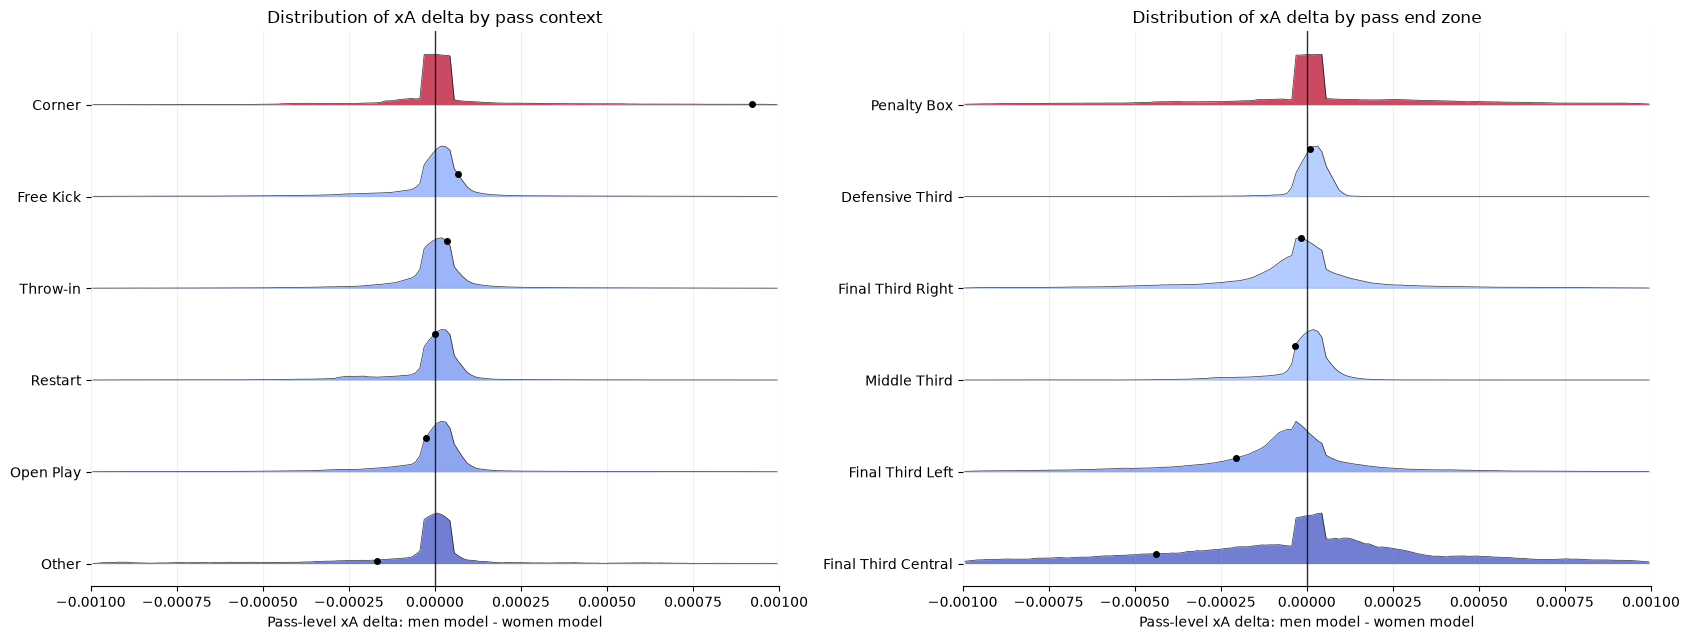

Note: ridgelines are smoothed histograms shown within [-0.001, +0.001] for readability. Each ridge is normalized to height 0.55, so shapes are comparable while group sizes are shown in the tables above.


In [19]:
def summarize_xa_by_group(group_column, min_passes=MIN_PASSES_PER_PASS_GROUP):
    """Summarize xA model differences for one categorical pass grouping."""
    summary = (
        xa_predictions.groupby(group_column)
        .agg(
            passes=("xa_delta", "size"),
            shot_assist_passes=("is_shot_assist", "sum"),
            observed_xa=("assisted_shot_xg", "sum"),
            men_downsampled_xa=("men_downsampled_model_xa", "sum"),
            women_xa=("women_model_xa", "sum"),
            aggregate_xa_delta=("xa_delta", "sum"),
            mean_xa_delta=("xa_delta", "mean"),
            median_xa_delta=("xa_delta", "median"),
            mean_men_downsampled_xa=("men_downsampled_model_xa", "mean"),
            mean_women_xa=("women_model_xa", "mean"),
        )
        .reset_index()
    )
    summary = summary[summary["passes"] >= min_passes].copy()
    return summary.sort_values("mean_xa_delta")


group_summaries = {}
for group_column in ["pass_context", "end_zone", "pass_height", "pass_outcome"]:
    summary = summarize_xa_by_group(group_column)
    group_summaries[group_column] = summary
    print(f"\n{group_column} groups with at least {MIN_PASSES_PER_PASS_GROUP:,} passes:")
    display(summary.round(5))


XA_GROUP_RIDGE_BINS = 160
XA_GROUP_DELTA_LIMIT = 0.001
XA_GROUP_SMOOTHING_WINDOW = 7
XA_GROUP_RIDGE_HEIGHT = 0.55
XA_GROUP_ROW_SPACING = 1.0


def plot_group_delta_ridgeline(axis, passes, summary, group_column, title):
    """Draw a ridgeline chart of pass-level xA deltas for one grouping."""
    if summary.empty:
        axis.set_title(title + " (no groups)")
        return

    group_order = summary.sort_values("mean_xa_delta")[group_column].tolist()
    distribution_rows = passes[passes[group_column].isin(group_order)].copy()

    x_min, x_max = -XA_GROUP_DELTA_LIMIT, XA_GROUP_DELTA_LIMIT

    bin_edges = np.linspace(x_min, x_max, XA_GROUP_RIDGE_BINS + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    smoothing_kernel = np.ones(XA_GROUP_SMOOTHING_WINDOW) / XA_GROUP_SMOOTHING_WINDOW

    cmap = plt.colormaps["coolwarm"]
    color_min = summary["mean_xa_delta"].min()
    color_max = summary["mean_xa_delta"].max()
    if np.isclose(color_min, color_max):
        color_min -= 0.001
        color_max += 0.001
    color_norm = plt.Normalize(color_min, color_max)

    y_positions = np.arange(len(group_order)) * XA_GROUP_ROW_SPACING

    for y_position, group_value in zip(y_positions, group_order):
        values = distribution_rows.loc[
            distribution_rows[group_column].eq(group_value),
            "xa_delta",
        ].dropna().to_numpy()

        if len(values) == 0:
            smoothed_density = np.zeros_like(bin_centers)
        else:
            histogram, _ = np.histogram(values, bins=bin_edges, density=True)
            smoothed_density = np.nan_to_num(np.convolve(histogram, smoothing_kernel, mode="same"))
            if smoothed_density.max() > 0:
                smoothed_density = smoothed_density / smoothed_density.max() * XA_GROUP_RIDGE_HEIGHT

        summary_row = summary[summary[group_column].eq(group_value)].iloc[0]
        ridge_color = cmap(color_norm(summary_row["mean_xa_delta"]))

        axis.fill_between(
            bin_centers,
            y_position,
            y_position + smoothed_density,
            color=ridge_color,
            alpha=0.72,
            linewidth=0,
        )
        axis.plot(
            bin_centers,
            y_position + smoothed_density,
            color="black",
            linewidth=0.55,
            alpha=0.75,
        )
        axis.hlines(y_position, x_min, x_max, color="gray", linewidth=0.35, alpha=0.35)

        mean_delta = summary_row["mean_xa_delta"]
        if x_min <= mean_delta <= x_max:
            mean_height = np.interp(mean_delta, bin_centers, smoothed_density)
            axis.scatter(mean_delta, y_position + mean_height, color="black", s=16, zorder=4)

    axis.axvline(0, color="black", linewidth=1.0, alpha=0.8)
    axis.set_yticks(y_positions)
    axis.set_yticklabels(group_order)
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_positions[0] - 0.25, y_positions[-1] + XA_GROUP_RIDGE_HEIGHT + 0.25)
    axis.set_xlabel("Pass-level xA delta: men model - women model")
    axis.set_title(title)
    axis.grid(axis="x", alpha=0.18)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
plot_group_delta_ridgeline(
    axes[0],
    xa_predictions,
    group_summaries["pass_context"],
    "pass_context",
    "Distribution of xA delta by pass context",
)
plot_group_delta_ridgeline(
    axes[1],
    xa_predictions,
    group_summaries["end_zone"],
    "end_zone",
    "Distribution of xA delta by pass end zone",
)
plt.tight_layout()
plt.show()

print(
    f"Note: ridgelines are smoothed histograms shown within [-{XA_GROUP_DELTA_LIMIT:.3f}, +{XA_GROUP_DELTA_LIMIT:.3f}] for readability. "
    f"Each ridge is normalized to height {XA_GROUP_RIDGE_HEIGHT}, so shapes are comparable while group sizes are shown in the tables above."
)


## 15. 按 position bucket 分析 xA 排名差异

这部分和 VAEP / xG notebook 的 position-bucket 分析保持一致：看每个位置组内的 Spearman、总 xA delta 和组内排名变化。


Position-bucket summary for women test-set players with at least 100 passes:


,position_bucket,players,passes,shot_assist_passes,observed_xa,spearman_men_vs_women_xa,aggregate_xa_delta,mean_xa_delta,median_xa_delta,mean_abs_xa_delta,mean_bucket_rank_delta,median_abs_bucket_rank_delta,max_abs_bucket_rank_delta
0,Fullback / Wing Back,170,44969,730,70.0636,0.9926,-0.2973,-0.0017,0.0013,0.0331,0.0,3.0,24.0
1,Center Back,152,45391,239,20.9368,0.9815,-0.6769,-0.0045,-0.0069,0.0255,0.0,3.0,33.0
2,Defensive Midfield,122,31043,531,46.7578,0.9822,-0.7152,-0.0059,-0.0040,0.0326,0.0,3.0,28.0
3,Wide Midfielder / Winger,93,16466,701,80.7452,0.9877,4.2086,0.0453,0.0346,0.0746,0.0,2.0,18.0
4,Other / Unknown,74,16191,27,2.0988,0.9568,-1.1339,-0.0153,-0.0091,0.0168,0.0,2.5,16.0
5,Forward,67,10398,442,46.2992,0.9798,2.8730,0.0429,0.0405,0.0610,0.0,2.0,12.0
6,Central Midfield,63,13422,405,41.1639,0.9874,0.6144,0.0098,0.0148,0.0453,0.0,2.0,7.0
7,Attacking Midfield,34,7764,295,28.8427,0.9844,0.0649,0.0019,0.0028,0.0537,0.0,1.0,5.0


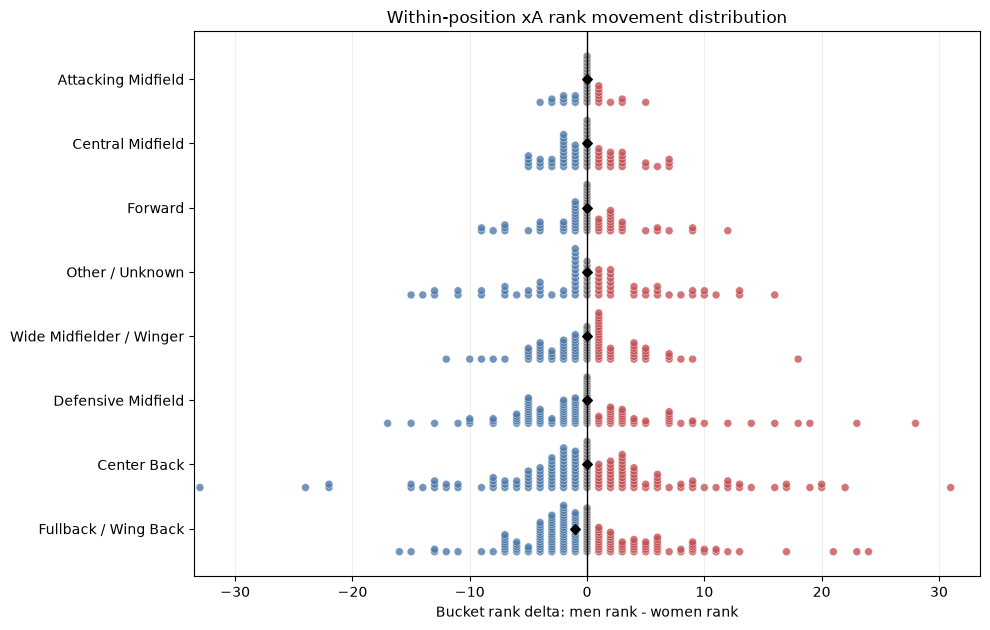


Players with largest within-bucket rank changes:


,player_id,player_name,primary_position,position_bucket,pass_count,observed_xa,men_downsampled_xa,women_xa,xa_delta,bucket_men_rank,bucket_women_rank,bucket_rank_delta
266,19777,Niamh Fahey,Center Back,Center Back,105,0.2002,0.1556,0.0889,0.0667,61.0,94.0,-33.0
1146,323561,Emilie Bragstad,Center Back,Center Back,347,0.0000,0.0396,0.0850,-0.0454,126.0,95.0,31.0
43,5003,Emily Ann Sonnett,Right Defensive Midfield,Defensive Midfield,149,0.0348,0.0573,0.1625,-0.1052,118.0,90.0,28.0
233,15620,Katie McCabe,Right Back,Fullback / Wing Back,147,0.0669,0.3038,0.4118,-0.1079,92.0,68.0,24.0
383,31536,Millie Turner,Left Center Back,Center Back,480,0.0000,0.1800,0.1111,0.0689,56.0,80.0,-24.0
1094,229194,Olga Ahtinen,Right Defensive Midfield,Defensive Midfield,138,0.2324,0.1720,0.2481,-0.0761,85.0,62.0,23.0
247,16386,Lucy Hope,Right Wing Back,Fullback / Wing Back,132,0.2508,0.1292,0.2042,-0.0750,133.0,110.0,23.0
928,123782,Laura Pucks,Left Center Back,Center Back,204,0.0335,0.0291,0.0597,-0.0307,136.0,114.0,22.0
2,4636,Maria Thorisdottir,Center Back,Center Back,143,0.0823,0.1104,0.0800,0.0304,75.0,97.0,-22.0
346,26093,Gun Nathalie Björn,Left Center Back,Center Back,115,0.0000,0.0568,0.0420,0.0149,107.0,129.0,-22.0


In [20]:
player_xa_by_position = player_xa_comparison.copy()

if player_xa_by_position.empty:
    print("No players available for position-bucket summary after filtering.")
else:
    player_xa_by_position["bucket_men_rank"] = player_xa_by_position.groupby("position_bucket")[
        "men_downsampled_xa"
    ].rank(ascending=False, method="min")
    player_xa_by_position["bucket_women_rank"] = player_xa_by_position.groupby("position_bucket")[
        "women_xa"
    ].rank(ascending=False, method="min")
    player_xa_by_position["bucket_rank_delta"] = (
        player_xa_by_position["bucket_men_rank"] - player_xa_by_position["bucket_women_rank"]
    )
    player_xa_by_position["abs_bucket_rank_delta"] = player_xa_by_position["bucket_rank_delta"].abs()

    bucket_summary_rows = []
    for position_bucket, bucket_players in player_xa_by_position.groupby("position_bucket"):
        bucket_summary_rows.append(
            {
                "position_bucket": position_bucket,
                "players": len(bucket_players),
                "passes": int(bucket_players["pass_count"].sum()),
                "shot_assist_passes": int(bucket_players["shot_assist_count"].sum()),
                "observed_xa": bucket_players["observed_xa"].sum(),
                "spearman_men_vs_women_xa": spearman_if_available(
                    bucket_players["men_downsampled_xa"],
                    bucket_players["women_xa"],
                    min_observations=MIN_PLAYERS_FOR_BUCKET_SPEARMAN,
                ),
                "aggregate_xa_delta": bucket_players["xa_delta"].sum(),
                "mean_xa_delta": bucket_players["xa_delta"].mean(),
                "median_xa_delta": bucket_players["xa_delta"].median(),
                "mean_abs_xa_delta": bucket_players["abs_xa_delta"].mean(),
                "mean_bucket_rank_delta": bucket_players["bucket_rank_delta"].mean(),
                "median_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].median(),
                "max_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].max(),
            }
        )

    position_bucket_xa_summary = (
        pd.DataFrame(bucket_summary_rows)
        .sort_values(["players", "passes"], ascending=False)
        .reset_index(drop=True)
    )

    print("Position-bucket summary for women test-set players with at least", MIN_PASSES_PER_PLAYER, "passes:")
    display(position_bucket_xa_summary.round(4))

    ordered_buckets = position_bucket_xa_summary.sort_values("players", ascending=False)["position_bucket"].tolist()
    rank_distribution_rows = player_xa_by_position.dropna(subset=["bucket_rank_delta"]).copy()
    RANK_STACK_HEIGHT = 0.72
    RANK_STACK_POINT_STEP = 0.09
    RANK_STACK_BOTTOM = -RANK_STACK_HEIGHT / 2

    fig, axis = plt.subplots(figsize=(10, max(6, 0.55 * len(ordered_buckets) + 2)))
    for y_index, position_bucket in enumerate(ordered_buckets):
        bucket_rank_values = rank_distribution_rows.loc[
            rank_distribution_rows["position_bucket"].eq(position_bucket),
            "bucket_rank_delta",
        ].to_numpy()
        if len(bucket_rank_values) == 0:
            continue

        y_offsets = np.zeros_like(bucket_rank_values, dtype=float)
        unique_rank_values, rank_group_ids = np.unique(bucket_rank_values, return_inverse=True)
        max_stack_size = max(np.bincount(rank_group_ids))
        stack_step = min(
            RANK_STACK_POINT_STEP,
            RANK_STACK_HEIGHT / max(max_stack_size - 1, 1),
        )
        for rank_group_id in range(len(unique_rank_values)):
            matching_points = np.flatnonzero(rank_group_ids == rank_group_id)
            y_offsets[matching_points] = RANK_STACK_BOTTOM + np.arange(len(matching_points)) * stack_step

        rank_colors = np.where(
            bucket_rank_values > 0,
            "#C44E52",
            np.where(bucket_rank_values < 0, "#4C78A8", "#777777"),
        )
        axis.scatter(
            bucket_rank_values,
            y_index + y_offsets,
            color=rank_colors,
            alpha=0.78,
            s=32,
            edgecolors="white",
            linewidths=0.35,
        )
        axis.scatter(
            np.median(bucket_rank_values),
            y_index,
            color="black",
            marker="D",
            s=24,
            zorder=4,
        )

    rank_limit = rank_distribution_rows["bucket_rank_delta"].abs().max()
    if pd.isna(rank_limit) or rank_limit == 0:
        rank_limit = 1
    axis.axvline(0, color="black", linewidth=1)
    axis.set_xlim(-rank_limit - 0.5, rank_limit + 0.5)
    axis.set_yticks(np.arange(len(ordered_buckets)))
    axis.set_yticklabels(ordered_buckets)
    axis.set_xlabel("Bucket rank delta: men rank - women rank")
    axis.set_title("Within-position xA rank movement distribution")
    axis.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()

    print("\nPlayers with largest within-bucket rank changes:")
    display(
        player_xa_by_position.sort_values("abs_bucket_rank_delta", ascending=False)[
            [
                "player_id",
                "player_name",
                "primary_position",
                "position_bucket",
                "pass_count",
                "observed_xa",
                "men_downsampled_xa",
                "women_xa",
                "xa_delta",
                "bucket_men_rank",
                "bucket_women_rank",
                "bucket_rank_delta",
            ]
        ]
        .head(25)
        .round(4)
    )


## 16. Read-out

这个 notebook 最后应该回答：

1. 男足训练的 xA 模型和女足训练的 xA 模型，在同一批女足 test passes 上给出的球员 xA 排名有多一致？
2. 两个模型的差异是否集中在某些 pass profile 上？
3. 差异是否集中在某些传球终点区域、传球上下文或 position bucket？

如果 xA 的 Spearman 接近 xG / xT，说明 chance-creation pass model 在跨性别迁移上比较稳定；如果明显低于 xG / xT 或在某些 pass profile 上偏差集中，就说明助攻前传球的价值估计比 shot-only / location-only 指标更容易受训练数据分布影响。
